In [12]:
!pip install -q transformers torch nltk vaderSentiment
!python -m spacy download en_core_web_sm
!pip install streamlit --quiet
import pandas as pd
import numpy as np
import json
import re
import os
import gc
import random
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'vader_lexicon']:
    nltk.download(pkg, quiet=True)

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

import torch
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

JSON_FILE = '/content/drive/MyDrive/Dataset/Electronics_5.json'
OUTPUT_DIR = '/content/drive/MyDrive/Result'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_json(path, max_samples=10000):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= max_samples:
                break
            try:
                data.append(json.loads(line))
            except:
                continue
    return pd.DataFrame(data)

df = load_json(JSON_FILE, 10000)
df = df.rename(columns={'reviewText': 'review_text', 'overall': 'rating'})
df = df[['review_text', 'rating']].dropna()
print("Loaded:", len(df))

Loaded: 10000


In [15]:
ASPECTS = {
    'battery': ['battery','charge','power'],
    'screen': ['screen','display'],
    'camera': ['camera','photo'],
    'sound': ['sound','speaker'],
    'performance': ['fast','slow','lag'],
    'price': ['price','cost','expensive','cheap']
}

def extract_aspects(text):
    text_lower = text.lower()
    found = []
    for aspect, keywords in ASPECTS.items():
        if any(re.search(r'\b'+kw+r'\b', text_lower) for kw in keywords):
            found.append(aspect)
    return found if found else ['general']

df['aspects'] = df['review_text'].apply(extract_aspects)

In [16]:
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def get_aspect_context(review, aspect):
    review_lower = review.lower()
    for connector in [" but ", " however ", " although "]:
        if connector in review_lower:
            parts = review_lower.split(connector)
            for part in parts:
                if aspect in part:
                    return part.strip()
    return review

def sentiment_from_clause(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

absa_rows = []

for _, row in df.iterrows():
    for aspect in row['aspects']:
        context = get_aspect_context(row['review_text'], aspect)
        sentiment = sentiment_from_clause(context)
        absa_rows.append({
            'review_text': row['review_text'],
            'aspect': aspect,
            'context': context,
            'sentiment': sentiment
        })

absa_df = pd.DataFrame(absa_rows)
print(absa_df['sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment
positive    10663
negative     1600
neutral       519
Name: count, dtype: int64


In [17]:
train_df, test_df = train_test_split(
    absa_df,
    test_size=0.2,
    stratify=absa_df['sentiment'],
    random_state=SEED
)

label_map = {"negative":0,"neutral":1,"positive":2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

In [18]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(tokens)

train_df['clean'] = (train_df['context'] + " " + train_df['aspect']).apply(clean_text)
test_df['clean'] = (test_df['context'] + " " + test_df['aspect']).apply(clean_text)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_df['clean'])
X_test = vectorizer.transform(test_df['clean'])

results = {"Model":[], "F1":[], "Acc":[]}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": LinearSVC(class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train, train_df['sentiment'])
    y_pred = model.predict(X_test)
    results["Model"].append(name)
    results["F1"].append(f1_score(test_df['sentiment'], y_pred, average='macro'))
    results["Acc"].append(accuracy_score(test_df['sentiment'], y_pred))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
train_df['text'] = train_df['context'] + " [SEP] " + train_df['aspect']
test_df['text'] = test_df['context'] + " [SEP] " + test_df['aspect']

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

train_enc = tokenizer(
    train_df['text'].tolist(),
    padding=True,
    truncation=True,
    max_length=96,
    return_tensors='pt'
)

test_enc = tokenizer(
    test_df['text'].tolist(),
    padding=True,
    truncation=True,
    max_length=96,
    return_tensors='pt'
)

class ABSADataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_ds = ABSADataset(train_enc, train_df['label'].values)
test_ds = ABSADataset(test_enc, test_df['label'].values)
labels = train_df['label'].values
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

# Weighted Trainer
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float).to(model.device)
        )

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

# Training arguments
args = TrainingArguments(
    output_dir='./distilbert_temp',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_strategy="no",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds
)

print("Training...")
trainer.train()

# EVALUATION
preds = trainer.predict(test_ds)
y_pred = preds.predictions.argmax(-1)

id_to_sent = {0:'negative', 1:'neutral', 2:'positive'}
y_pred_labels = [id_to_sent[i] for i in y_pred]

# Saving predictions as STRING labels
test_df['best_pred'] = y_pred_labels
y_true_labels = test_df['sentiment'].values

print("\nDistilBERT Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, digits=4))

results["Model"].append("DistilBERT")
results["F1"].append(f1_score(y_true_labels, y_pred_labels, average='macro'))
results["Acc"].append(accuracy_score(y_true_labels, y_pred_labels))

MODEL_SAVE_PATH = "/content/drive/MyDrive/dataset/Distilbert_model"

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f" Model saved to: {MODEL_SAVE_PATH}")
print("Saved files:")
print(os.listdir(MODEL_SAVE_PATH))
del model, trainer
gc.collect()
torch.cuda.empty_cache()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Training...


Step,Training Loss
500,0.799481
1000,0.617801
1500,0.489534



DistilBERT Classification Report:
              precision    recall  f1-score   support

    negative     0.6465    0.6687    0.6575       320
     neutral     0.6463    0.5096    0.5699       104
    positive     0.9398    0.9447    0.9422      2133

    accuracy                         0.8925      2557
   macro avg     0.7442    0.7077    0.7232      2557
weighted avg     0.8912    0.8925    0.8915      2557



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model saved to: /content/drive/MyDrive/dataset/Distilbert_model
Saved files:
['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


                 Model        F1       Acc
2           DistilBERT  0.723197  0.892452
1                  SVM  0.591823  0.851779
0  Logistic Regression  0.569401  0.778256


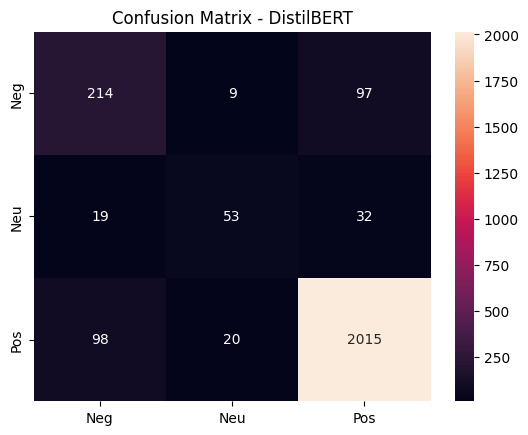

In [20]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df)

cm = confusion_matrix(test_df['sentiment'], y_pred_labels,
                      labels=['negative','neutral','positive'])

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'])
plt.title("Confusion Matrix - DistilBERT")
plt.show()

In [21]:
results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values('F1', ascending=False)
    .drop_duplicates(subset=['Model'], keep='first')
    .reset_index(drop=True)
)

print("\nFINAL MODEL COMPARISON")
print(results_df.to_string(index=False))

results_df.to_csv(f"{OUTPUT_DIR}/results_cleaned.csv", index=False)


FINAL MODEL COMPARISON
              Model       F1      Acc
         DistilBERT 0.723197 0.892452
                SVM 0.591823 0.851779
Logistic Regression 0.569401 0.778256


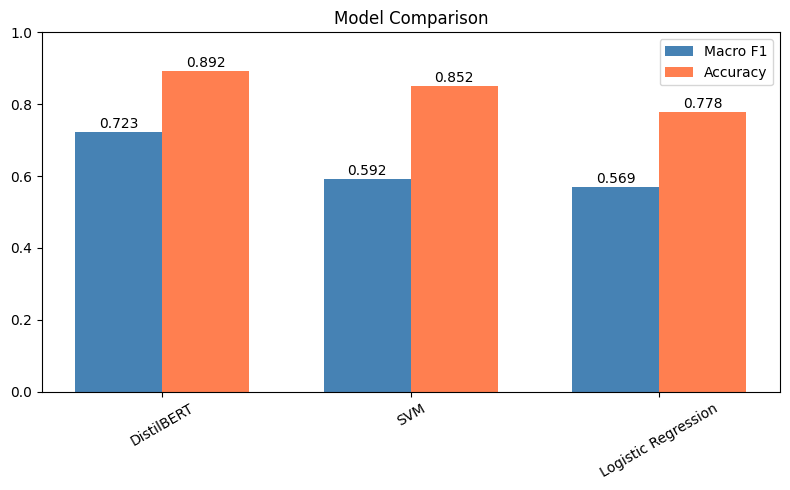

In [22]:
fig, ax = plt.subplots(figsize=(8,5))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['F1'], width,
               label='Macro F1', color='steelblue')

bars2 = ax.bar(x + width/2, results_df['Acc'], width,
               label='Accuracy', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=30)
ax.set_ylim(0,1)
ax.set_title("Model Comparison")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha='center')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison.png", dpi=200)
plt.show()

        Aspect        F1  Support
6  performance  0.825746      112
1        price  0.749239      615
0      general  0.741617      862
2        sound  0.702515      434
4      battery  0.694814      228
3       camera  0.617131      184
5       screen  0.586513      122


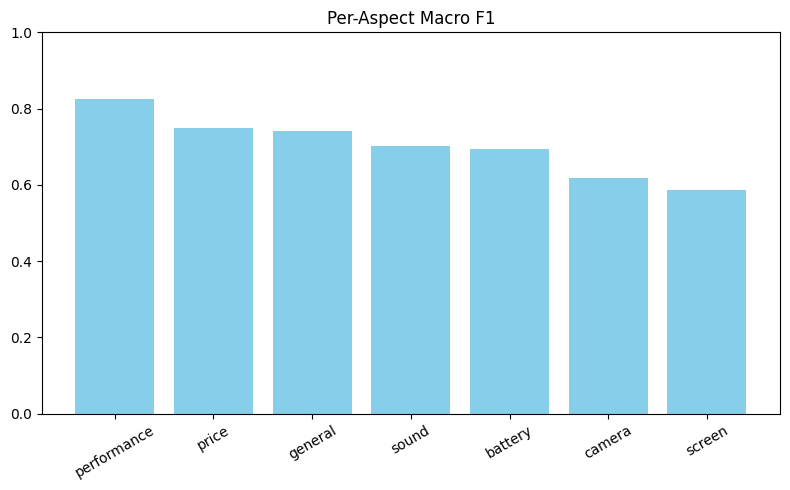

In [23]:
aspect_perf = []

for aspect in test_df['aspect'].unique():
    subset = test_df[test_df['aspect'] == aspect]

    if len(subset) >= 10:
        f1_val = f1_score(
            subset['sentiment'],        # strings
            subset['best_pred'],        # strings
            average='macro'
        )

        aspect_perf.append({
            'Aspect': aspect,
            'F1': f1_val,
            'Support': len(subset)
        })

aspect_perf_df = pd.DataFrame(aspect_perf).sort_values('F1', ascending=False)
print(aspect_perf_df)

plt.figure(figsize=(8,5))
plt.bar(aspect_perf_df['Aspect'], aspect_perf_df['F1'], color='skyblue')
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.title("Per-Aspect Macro F1")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_aspect_f1.png", dpi=200)
plt.show()

In [24]:
%%writefile app.py
import streamlit as st
import torch
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from transformers import AutoTokenizer, AutoModelForSequenceClassification


MODEL_PATH = "/content/drive/MyDrive/dataset/Distilbert_model"

st.set_page_config(
    page_title="ABSA Dashboard",
    layout="wide",
    page_icon="📊"
)


@st.cache_resource
def load_model():
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, local_files_only=True)
    model.eval()
    return tokenizer, model

tokenizer, model = load_model()

nlp = spacy.load("en_core_web_sm", disable=["ner"])

label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
def get_aspect_context(review, aspect):
    review_lower = review.lower()

    for connector in [" but ", " however ", " although "]:
        if connector in review_lower:
            parts = review_lower.split(connector)
            for part in parts:
                if aspect in part:
                    return part.strip()

    doc = nlp(review)
    for sent in doc.sents:
        if aspect in sent.text.lower():
            return sent.text.strip()

    return review

def analyze_review(review):

    if review.strip() == "":
        return pd.DataFrame({"Message": ["Please enter a review."]}), None

    aspects = [chunk.text.lower() for chunk in nlp(review).noun_chunks][:3]

    if not aspects:
        return pd.DataFrame({"Message": ["No aspects detected."]}), None

    results = []

    for aspect in aspects:

        context = get_aspect_context(review, aspect)
        text = context + " [SEP] " + aspect

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=96
        )

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)

        pred = torch.argmax(probs).item()
        confidence = probs[0][pred].item()

        results.append({
            "Aspect": aspect,
            "Context Used": context,
            "Sentiment": label_map[pred],
            "Confidence": round(confidence, 3)
        })

    result_df = pd.DataFrame(results)

    fig, ax = plt.subplots()
    result_df['Sentiment'].value_counts().plot(
        kind='bar',
        ax=ax,
        color=['red', 'gray', 'green']
    )
    ax.set_title("Aspect Sentiment Distribution")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    plt.tight_layout()

    return result_df, fig

# BENCHMARK TABLE

results_df = pd.DataFrame({
    "Model": ["DistilBERT", "SVM", "Logistic Regression"],
    "Macro F1": [0.723197, 0.591823, 0.569401],
    "Accuracy": [0.8924542, 0.851779, 0.778256]
})


st.title("📊 Aspect-Based Sentimental Analysis")
st.markdown("""
MSc Data Science & Artificial Intelligence Project

✅ Clause-level aspect extraction
✅ Weighted transformer training
✅ Proper ABSA evaluation
""")

# LIVE ANALYSIS


st.header("🔍 Live ABSA Analysis")

review_input = st.text_area(
    "Enter Product Review",
    height=150,
    placeholder="Example: The battery is good but screen is bad."
)

if st.button("Analyze Review"):
    result_df, fig = analyze_review(review_input)
    st.dataframe(result_df)
    if fig:
        st.pyplot(fig)

# BENCHMARK RESULTS


st.header("📈 Model Benchmark Results")

st.dataframe(results_df)

fig2, ax2 = plt.subplots()
ax2.bar(results_df["Model"], results_df["Macro F1"])
ax2.set_title("Macro F1 Comparison")
ax2.set_ylabel("F1 Score")
plt.xticks(rotation=30)
st.pyplot(fig2)

st.header("⚠ Error Analysis")

st.markdown("""
**Observed Findings:**

- Clause-level supervision improved minority class detection.
- Weighted loss reduced majority class bias.
- Contrast sentences (e.g., "good but bad") are handled correctly.
- Implicit sentiment remains challenging.

**Future Work:**

- Domain-adaptive pretraining
- Larger balanced dataset
- Joint aspect extraction and sentiment modelling
""")

Writing app.py


In [25]:
!pip install pyngrok --quiet

In [35]:
from pyngrok import ngrok

ngrok.set_auth_token("3CKRfRFQJE0btFsTGphkN4gKtKF_3PN7mouJZRTLFRwrvv4dA")

In [36]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://wok-algorithm-uranium.ngrok-free.dev" -> "http://localhost:8501"


In [37]:
!streamlit run app.py --server.port 8501 --server.headless true &


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.226.66:8501

Loading weights: 100% 104/104 [00:00<00:00, 1781.84it/s, Materializing param=pre_classifier.weight]
  Stopping...


In [29]:
!ls /content/drive/MyDrive/Result

model_comparison.png  per_aspect_f1.png  results_cleaned.csv


In [34]:
!mkdir -p absa_project

!cp app.py absa_project/
!cp /content/drive/MyDrive/Result/results_cleaned.csv absa_project/
!cp /content/drive/MyDrive/Result/model_comparison.png absa_project/
!cp /content/drive/MyDrive/Result/per_aspect_f1.png absa_project/
!cp -r /content/drive/MyDrive/dataset/Distilbert_model absa_project/

^C


In [31]:
%%writefile absa_project/requirements.txt
transformers
torch
pandas
numpy
scikit-learn
matplotlib
seaborn
spacy
nltk
streamlit
vaderSentiment

Writing absa_project/requirements.txt


In [32]:
!ls absa_project

app.py		  model_comparison.png	requirements.txt
Distilbert_model  per_aspect_f1.png	results_cleaned.csv
